In [28]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv("Coffee.csv")
df.head()

,Unnamed: 0,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
0,0,2015,Argentina,13051.0,14887.0,2.6,2.7,26614.0
1,1,2015,Argentina,13131.0,15055.0,2.6,3.0,27019.0
2,2,2015,Argentina,13305.0,15075.0,2.7,NaN,27232.0
3,3,2015,Brazil,21070.0,36806.0,1.9,1.9,54721.0
4,4,2015,Canada,18063.0,21734.0,3.9,4.0,38987.0


1. How many rows and columns are present in the dataset?

In [30]:
df.shape #The dataset contains 520 rows and 8 columns.

(520, 8)

2. What are the names of all columns in the dataset?

In [31]:
df.columns

Index(['Unnamed: 0', 'Year', 'Country', 'Domestic Consumption', 'Exports',
       'Import Price', 'Export Price', 'Total Production'],
      dtype='str')

3. What is the data type of each column?

In [32]:
df.dtypes

Unnamed: 0                int64
Year                      int64
Country                     str
Domestic Consumption    float64
Exports                 float64
Import Price            float64
Export Price            float64
Total Production        float64
dtype: object

4. Display the first 5 rows of the dataset.

In [33]:
df.head()

,Unnamed: 0,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
0,0,2015,Argentina,13051.0,14887.0,2.6,2.7,26614.0
1,1,2015,Argentina,13131.0,15055.0,2.6,3.0,27019.0
2,2,2015,Argentina,13305.0,15075.0,2.7,NaN,27232.0
3,3,2015,Brazil,21070.0,36806.0,1.9,1.9,54721.0
4,4,2015,Canada,18063.0,21734.0,3.9,4.0,38987.0


5. Display the last 5 rows of the dataset.

In [34]:
df.tail()

,Unnamed: 0,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
515,515,2023,USA,28629.0,0.0,5.3,0.0,0.0
516,516,2023,USA,28875.0,0.0,5.2,0.0,0.0
517,517,2023,Vietnam,NaN,34342.0,2.9,3.2,52222.0
518,518,2023,Vietnam,18557.0,34695.0,3.2,2.9,52867.0
519,519,2023,Vietnam,18615.0,34840.0,3.0,NaN,52639.0


6. Which columns contain missing values?


In [35]:
df.isnull().sum()

Unnamed: 0               0
Year                     0
Country                  0
Domestic Consumption    26
Exports                 26
Import Price            26
Export Price            26
Total Production        26
dtype: int64

In [36]:
df = df.dropna()

7. How many unique countries are present in the dataset?

In [37]:
df['Country'].unique() #20 unique countries

<StringArray>
[   'Argentina',       'Brazil',       'Canada',        'Chile',
        'China',     'Colombia',     'Ethiopia',       'France',
      'Germany',        'India',    'Indonesia',        'Italy',
        'Kenya',       'Mexico',         'Peru', 'South Africa',
     'Thailand',       'Turkey',          'USA',      'Vietnam']
Length: 20, dtype: str

8. How many records are available for each year?


In [38]:
df['Year'].value_counts().sort_index()

Year
2015    53
2016    43
2017    50
2018    32
2019    44
2020    47
2021    45
2022    44
2023    41
Name: count, dtype: int64

9. How many records are available for each country?

In [39]:
df['Country'].value_counts()

Country
Chile           25
Mexico          25
Colombia        24
France          24
South Africa    24
Argentina       22
Germany         22
India           21
China           20
Indonesia       20
Italy           20
Kenya           20
Brazil          19
Vietnam         19
Thailand        18
USA             18
Canada          16
Turkey          15
Ethiopia        14
Peru            13
Name: count, dtype: int64

10. Find the minimum, maximum, and average of total production.

In [40]:
df['Total Production'].describe()

count       399.000000
mean      47127.937343
std       49451.906679
min           0.000000
25%       16464.000000
50%       41310.000000
75%       63110.000000
max      264565.000000
Name: Total Production, dtype: float64

In [41]:
min_val = df['Total Production'].min()
max_val = df['Total Production'].max()
mean_val = df['Total Production'].mean()

print(f"Min: {min_val}, Max: {max_val}, Mean: {mean_val}")


Min: 0.0, Max: 264565.0, Mean: 47127.9373433584



11) Which country has the highest total production in a single record?

In [42]:
df[df['Total Production'] == df['Total Production'].max()]['Country'].iloc[0]

'China'


12) Are there any rows where total production is missing or zero?

In [43]:
df[(df['Total Production'].isnull()) | (df['Total Production'] == 0)]

,Unnamed: 0,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
27,27,2015,Germany,8514.0,11030.0,3.2,3.5,0.0
28,28,2015,Germany,8514.0,11030.0,3.2,3.5,0.0
29,29,2015,Germany,8887.0,11273.0,3.4,3.6,0.0
30,30,2015,Germany,8396.0,10988.0,3.0,3.7,0.0
32,32,2015,Germany,8121.0,11043.0,3.1,3.7,0.0
64,64,2015,USA,25244.0,0.0,4.4,0.0,0.0
66,66,2015,USA,24831.0,0.0,4.2,0.0,0.0
94,94,2016,Germany,8792.0,11048.0,3.3,3.6,0.0
95,95,2016,Germany,8670.0,10868.0,3.2,3.7,0.0
96,96,2016,Germany,8369.0,11295.0,3.0,3.8,0.0



13) What is the average import price across all records?

In [44]:
df['Import Price'].mean()

np.float64(3.149874686716792)


14) What is the total coffee production for each year?

In [53]:
tp_per_year = df.groupby('Year')['Total Production'].sum()
print("Total Production per Year:")
tp_per_year

Total Production per Year:


Year
2015    2124417.0
2016    1838344.0
2017    2013872.0
2018    1389364.0
2019    2089672.0
2020    2464222.0
2021    2484249.0
2022    2267730.0
2023    2132177.0
Name: Total Production, dtype: float64

In [50]:
plt.style.use("dark_background")

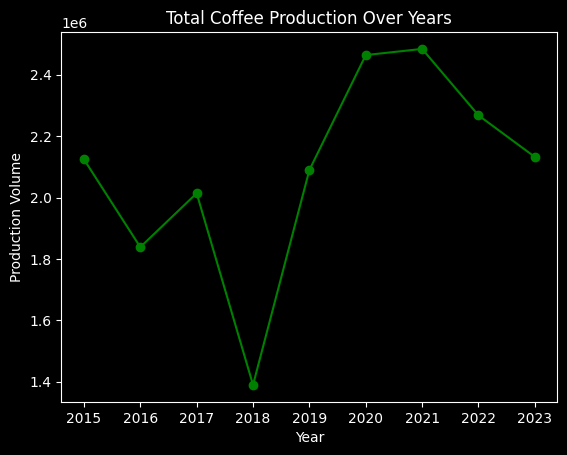

In [56]:
tp_per_year.plot(color='green', marker = "o")
plt.title('Total Coffee Production Over Years')
plt.ylabel('Production Volume')
plt.show()


15) Which are the top 5 countries based on total production?

In [ ]:
df.groupby('Country')['Total Production'].sum().nlargest(5)

Country
China        4705657.0
Mexico       1766204.0
India        1587604.0
France       1514875.0
Indonesia    1275296.0
Name: Total Production, dtype: float64


16) Which country has the highest average export price?

In [ ]:
df.groupby('Country')['Export Price'].mean().nlargest(1)

Country
Canada    4.2875
Name: Export Price, dtype: float64


17) Does domestic consumption exceed total production for any country?

In [67]:
df[df['Domestic Consumption'] > df['Total Production']]['Country'].unique()

<StringArray>
['Germany', 'USA']
Length: 2, dtype: str


18) Which country shows the highest growth in total production over the years?

In [70]:
def calculate_growth(group):
    first_year = group.sort_values('Year')['Total Production'].iloc[0]
    last_year = group.sort_values('Year')['Total Production'].iloc[-1]
    return last_year - first_year

In [71]:
growth = df.groupby('Country').apply(calculate_growth)
highest_growth_country = growth.idxmax()
print(f"\nCountry with Highest Growth: {highest_growth_country}")


Country with Highest Growth: China



19) Is there any relationship between export price and total production?

In [73]:
correlation = df['Export Price'].corr(df['Total Production'])
print(f"\nCorrelation between Export Price and Total Production: {correlation}")


Correlation between Export Price and Total Production: 0.3440041126275756



20) Write 4–5 lines summarizing key insights from the EDA.

### Key Insights from the EDA

The dataset consists of 520 rows and 8 columns, covering coffee production and pricing data across 20 countries from 2015 to 2023. A total of 26 missing values were observed in production and pricing-related columns, indicating minor data gaps.

China recorded the highest total production in a single year (264,565 in 2023) and also shows the highest overall production growth across the years. Additionally, China and India are among the top contributors to total coffee production.

Canada has the highest average export price among all countries. The overall average import price across the dataset is approximately 3.16.

There are several records where domestic consumption exceeds total production, suggesting that some countries rely on imports to meet demand. The correlation between export price and total production is moderately positive (≈0.34), indicating a weak-to-moderate relationship between pricing and production levels.